> 代码参考：`https://github.com/percent4/pytorch_transformer_chinese_text_classification`

# 1. 数据集预处理

- 主要通过对数据集的预处理得到字库与标签库，并把字库与标签分表序列化存储到文件。
    - 标签存储文件：`labels.pk`
    - 字库存储文件：`chars.pk`

In [1]:
import os
import pickle
import pandas as pd
from random import shuffle
from operator import itemgetter
from collections import Counter, defaultdict

## 1.1. 文件保存的封装实现

In [2]:
# pickle文件操作
class PickleFileOperator:
    def __init__(self, data=None, file_path=''):
        self.data = data
        self.file_path = file_path

    def save(self):
        with open(self.file_path, 'wb') as f:
            pickle.dump(self.data, f)

    def read(self):
        with open(self.file_path, "rb") as f:
            content = pickle.load(f)
        return content

## 1.2. 预处理数据集

- 通过对数据集的统计得到标签库与字库。

### （1）数据集预处理参数

In [3]:
# 数据集文件
DATASETS_DIR = "./datasets"
TRAIN_FILE_PATH = os.path.join(DATASETS_DIR, 'train.csv')   # 训练数据集
TEST_FILE_PATH = os.path.join(DATASETS_DIR, 'test.csv')     # 测试数据集

# 字库的最大数量
NUM_WORDS = 5500    # 用来限制字库的最大容量，

### （2）数据集预处理

- 打开数据集，读取标签与内容。
    - 对标签唯一化处理，得到标签库
    - 对内容，统计得到字库，字库是打乱后，随机取`NUM_WORDS`大的数量。这个操作是认为产生一些不在统计范围的字，降低模型训练的拟合性。

In [4]:
class FilePreprossing(object):
    def __init__(self, n):
        # 保留前n个高频字
        self.__n = n

    def _read_train_file(self):
        train_pd = pd.read_csv(TRAIN_FILE_PATH)
        label_list = train_pd['label'].unique().tolist()
        # 统计文字频数
        character_dict = defaultdict(int)
        for content in train_pd['content']:
            for key, value in Counter(content).items():
                character_dict[key] += value
        # 不排序
        sort_char_list = [(k, v) for k, v in character_dict.items()]
        shuffle(sort_char_list)
        # 排序
        # sort_char_list = sorted(character_dict.items(), key=itemgetter(1), reverse=True)
        print(f'数据集共计 {len(character_dict)} 汉字.')
        print('随机打乱后，前10个字的统计： ', sort_char_list[:10])
        # 保留前n个文字
        top_n_chars = [_[0] for _ in sort_char_list[:self.__n]]   # 这里只保留了前n个字。（注意：这里对汉字没有采用分词处理，而是直接处理字）
        print("最终字库的总数：", len(top_n_chars))
        return label_list, top_n_chars

    def run(self):
        label_list, top_n_chars = self._read_train_file()
        PickleFileOperator(data=label_list, file_path='labels.pk').save()
        PickleFileOperator(data=top_n_chars, file_path='chars.pk').save()


### （3）执行数据集预处理

In [5]:
processor = FilePreprossing(NUM_WORDS)
processor.run()

数据集共计 5259 汉字.
随机打乱后，前10个字的统计：  [('苗', 131), ('邀', 173), ('犀', 19), ('焰', 29), ('─', 15), ('鹜', 9), ('镌', 2), ('果', 5546), ('坯', 2), ('峙', 16)]
最终字库的总数： 5259


In [6]:
labels = PickleFileOperator(file_path='labels.pk').read()
print("标签：", labels)
content = PickleFileOperator(file_path='chars.pk').read()
print("字库的前10个字（随机打乱的，没有按照统计数量排序）：", content[:10])

标签： ['体育', '健康', '军事', '教育', '汽车']
字库的前10个字（随机打乱的，没有按照统计数量排序）： ['苗', '邀', '犀', '焰', '─', '鹜', '镌', '果', '坯', '峙']


--------

# 2. 数据集特征处理（数据集工程）

- 把数据集处理成在模型可以使用的格式：向量。
    - 模型训练
    - 模型测试
    - 模型评估
    - 模型推理
- 在PyTorch中需要处理成Dataset与DataLoader。
    - Dataset是数据集格式。
    - DataLoader是批次数据集格式。
- 数据集特征处理主要是文本向量化，向量化技术很多，这里采用的向量化方式：
    - 对字库编号，使用编号代替字，实现数值化，
    - 文本字符串就可以轻松转化为向量。
- 为了保证向量的维度形状一致，对每个句子都进行了对齐处理：
    - 指定一个对齐长度SENT_LENGTH
    - 大于SENT_LENGTH的句子截断处理
    - 小于SENT_LENGTH长度的进行补齐，补齐的字符统一采用PAD定义字符替代，补齐字符的编号采用PAD_NO定义的编号，一般用0
    - 如果碰见字库中没有的字，则使用UNK定义的字符替代。UNK的字符编号采用UNK_NO定义的编号，一般使用1。

In [7]:
import pandas as pd
import numpy as np
import torch as T
from torch.utils.data import Dataset, random_split

## 2.1. 读取标签库与字库

- 把上面与处理的字库与标签数值化：
    - 使用顺序编号，把编号与字与标签对应起来。
    - 采用字典存储标签与编码的对应关系，存储字与编号对应关系。
    - 后面可以通过字典把预测的编号还原为字与文本标签。

In [8]:
# 读取pickle文件
def load_file_file():
    labels = PickleFileOperator(file_path='labels.pk').read()
    chars = PickleFileOperator(file_path='chars.pk').read()
    label_dict = dict(zip(labels, range(len(labels))))
    char_dict = dict(zip(chars, range(len(chars))))
    return label_dict, char_dict

In [9]:
l_d, c_d = load_file_file()
print(l_d)
print(list(c_d.items())[:5])

{'体育': 0, '健康': 1, '军事': 2, '教育': 3, '汽车': 4}
[('苗', 0), ('邀', 1), ('犀', 2), ('焰', 3), ('─', 4)]


## 2.2. 读取数据集样本与标签

- 读取csv文件，一行一个样本。

In [10]:
# load csv file
def load_csv_file(file_path):
    df = pd.read_csv(file_path)
    samples, y_true = [], []
    for index, row in df.iterrows():
        y_true.append(row['label'])
        samples.append(row['content'])
    return samples, y_true

In [11]:
s, l = load_csv_file(TRAIN_FILE_PATH)
print(s[:2])
print(l[:2])

['中国“铁腰”与英超球队埃弗顿分道扬镳，闪电般转投谢联（本赛季成功升入英超），此事运作速度之快令人惊诧。针对李铁与埃弗顿“分手”的原因、与埃弗顿主帅莫耶斯矛盾以及铁子为何选择谢联，记者昨日采访了李铁的母亲王桂芹，李母道出了李铁与埃弗顿分开的真实原因。龙菲坚决让铁子走人记者在采访王桂芹时了解到，李铁离开埃弗顿主要是妻子龙菲建议。龙菲平时不太过问李铁的足球方面事宜，但是，因为李铁长时间不能在埃弗顿踢上球，龙菲也十分焦急。多次安慰李铁后，龙菲想这样下去也不是个办法，于是索性做出决定，让李铁离开埃弗顿，只要能踢上球，去哪支球队都行。但前提条件必须是英国的球队。王妈妈告诉记者：“媳妇龙菲一直在英国学习，这孩子特别懂事，一边学习，一边还要照顾女儿和李铁的日常生活。对于李铁与埃弗顿的前前后后，龙菲一直都了解内情，因此龙菲最后告诉李铁，就是埃弗顿再请我们，我们也不去了，只要能离开埃弗顿，去哪支球队踢球都行。”据悉，龙菲２００１年便在沈阳拿到了留学英国全额奖学金的录取通知书，而后，龙菲便一直在英国求学。红牌让李铁失去位置“拼命三郎”、“跑不死”、“体能王”，这些溢美之词都是称赞李铁的，不过，正是因为李铁防守时的动作过于凶狠，在英超的赛场上屡次领到红牌。过多的红牌让主帅莫耶斯逐渐对李铁失去了兴趣。对此，王妈妈向记者表示：“关于球队的相关事宜，我不太清楚。因为埃弗顿主教练莫耶斯一直都很器重李铁，因为莫耶斯的战术比较偏重防守。而在防守过程中，李铁也确实吃到过红牌，但是，我觉得教练组和俱乐部不能因为红牌的原因不让李铁上场吧。”许宏涛挽救李铁李铁成功转会埃弗顿的整个过程，国内足球著名的经纪人许宏涛功不可没。而李铁在埃弗顿后期四处碰壁的危难时刻，正是许宏涛的左右逢源，令李铁还能坚持在埃弗顿预备队踢球。后来，在埃弗顿摒弃李铁后，也正是许宏涛的人脉关系让李铁再次找到了位置。根据李铁与埃弗顿签订的合同，今年６月３０日，工作合同才到期。但是，考虑到李铁与俱乐部的关系日益紧张，许宏涛便提早联系了英超其他球队，重点便是当时的英甲球队谢联。由于许宏涛是谢联董事会的成员，多次与俱乐部沟通李铁的事宜后，俱乐部最终同意了李铁加盟谢联。对李铁加盟谢联的事情，王桂芹不愿多谈。她只是表示：“许宏涛一直在帮助李铁，特别是在英国，许宏涛非常熟悉那里的环境，李铁也非常信任他，这下也好，李铁可以同郝海东一块踢球了。”首席记者贾

## 2.3. 样本特征处理：句子向量化

- 使用上面标签库与字库的编号字段，把每个样本的句子数值化。

### （1）文本向量化处理的参数

In [12]:
PAD = '<PAD>'
PAD_NO = 0
UNK = '<UNK>'
UNK_NO = 1
START_NO = UNK_NO + 1
SENT_LENGTH = 200

### (2) 文本向量化

- 对句子进行长度对齐，并根据编号字典，对句子数值化。

In [13]:
# 文本预处理
def text_feature(labels, contents, label_dict, char_dict):
    samples, y_true = [], []
    for s_label, s_content in zip(labels, contents):
        y_true.append(label_dict[s_label])
        train_sample = []
        for char in s_content:
            if char in char_dict:
                train_sample.append(START_NO + char_dict[char])
            else:
                train_sample.append(UNK_NO)
        # 补充或截断
        if len(train_sample) < SENT_LENGTH:
            samples.append(train_sample + ([PAD_NO] * (SENT_LENGTH - len(train_sample))))
        else:
            samples.append(train_sample[:SENT_LENGTH])

    return samples, y_true

In [14]:
digit_s, digit_l = text_feature(l, s, l_d, c_d)
print("对齐后，并数值化的句子：\n", digit_s[:2])
print("数值化后的标签：\n", digit_l[:2])

对齐后，并数值化的句子：
 [[2820, 2136, 5193, 4570, 1699, 3463, 1470, 806, 3693, 376, 4134, 1176, 66, 581, 4857, 991, 1937, 1222, 3982, 3106, 2250, 3297, 3264, 1734, 2426, 649, 93, 4867, 3663, 3656, 179, 1287, 417, 1797, 806, 3693, 3285, 3982, 2551, 4889, 869, 3671, 3223, 3625, 3402, 3498, 3000, 1086, 1514, 1168, 389, 1696, 1775, 3636, 4570, 1470, 1176, 66, 581, 5193, 4857, 4426, 3463, 634, 3531, 3173, 210, 1470, 1176, 66, 581, 2743, 4107, 805, 2042, 1196, 2618, 474, 353, 4054, 4570, 3765, 3632, 2334, 2650, 1212, 2426, 649, 3982, 1538, 3612, 1006, 672, 3504, 2946, 664, 3636, 4570, 634, 3602, 305, 3366, 3905, 4057, 3982, 3636, 3602, 991, 4202, 664, 3636, 4570, 1470, 1176, 66, 581, 4857, 2805, 634, 1203, 4178, 3531, 3173, 389, 505, 1269, 3657, 4547, 1306, 4570, 3765, 2660, 1086, 1538, 3612, 907, 3504, 2946, 3366, 3905, 4057, 215, 664, 793, 2711, 3982, 3636, 4570, 5018, 2805, 1176, 66, 581, 2743, 2291, 1938, 5249, 3765, 505, 1269, 5043, 4976, 389, 505, 1269, 2035, 215, 882, 29, 777, 3889, 3636, 4570,

## 2.4 生成PyTorch的数据集格式

- 因为我们使用PyTorch，所以采用PyTorch的Dataset实现数据集。方便后面训练，验证，测试使用。

In [15]:
# Dataset类实现
class CSVDataset(Dataset):
    # load the dataset
    def __init__(self, file_path):
        label_dict, char_dict = load_file_file()  # 读取标签库与字库
        samples, y_true = load_csv_file(file_path) # 加载数据集样本
        x, y = text_feature(y_true, samples, label_dict, char_dict)
        # 转换为张量
        self.X = T.from_numpy(np.array(x)).long()
        self.y = T.from_numpy(np.array(y))

    # 数据集样本数
    def __len__(self):
        return len(self.X)

    # 返回指定索引的数据样本与标签，这是下标运算符。
    def __getitem__(self, idx):
        return [self.X[idx], self.y[idx]]

    # 根据比例把数据集分成训练集与测试集。
    def get_splits(self, n_test=0.3):
        # determine sizes
        test_size = round(n_test * len(self.X))
        train_size = len(self.X) - test_size
        # calculate the split
        return random_split(self, [train_size, test_size])

In [16]:
ds = CSVDataset(TRAIN_FILE_PATH)
print(ds[0])

[tensor([2820, 2136, 5193, 4570, 1699, 3463, 1470,  806, 3693,  376, 4134, 1176,
          66,  581, 4857,  991, 1937, 1222, 3982, 3106, 2250, 3297, 3264, 1734,
        2426,  649,   93, 4867, 3663, 3656,  179, 1287,  417, 1797,  806, 3693,
        3285, 3982, 2551, 4889,  869, 3671, 3223, 3625, 3402, 3498, 3000, 1086,
        1514, 1168,  389, 1696, 1775, 3636, 4570, 1470, 1176,   66,  581, 5193,
        4857, 4426, 3463,  634, 3531, 3173,  210, 1470, 1176,   66,  581, 2743,
        4107,  805, 2042, 1196, 2618,  474,  353, 4054, 4570, 3765, 3632, 2334,
        2650, 1212, 2426,  649, 3982, 1538, 3612, 1006,  672, 3504, 2946,  664,
        3636, 4570,  634, 3602,  305, 3366, 3905, 4057, 3982, 3636, 3602,  991,
        4202,  664, 3636, 4570, 1470, 1176,   66,  581, 4857, 2805,  634, 1203,
        4178, 3531, 3173,  389,  505, 1269, 3657, 4547, 1306, 4570, 3765, 2660,
        1086, 1538, 3612,  907, 3504, 2946, 3366, 3905, 4057,  215,  664,  793,
        2711, 3982, 3636, 4570, 5018, 2

# 3. 词嵌入处理

- 一般会直接使用词嵌入，但是这里对汉字使用预训练的词嵌入方式，对句子进行特征向量化处理，可以确保模型训练效果更好。
    - 这里的预训练模型，采用维基百科中语料库训练的词向量模型：`sgns.wiki.char.bz2`
    - 每个字都需要转换为向量。
- 下面使用上面字库中的字，查询已经预训练的词向量模型中训练的向量，得到满足我们这里使用的词向量

In [17]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable


In [18]:
import torch
from gensim.models import KeyedVectors

In [19]:
# 读取标签库与字库
label_dict, char_dict = load_file_file()
# 加载预训练的词向量模型
em_model = KeyedVectors.load_word2vec_format('./datasets/sgns.wiki.char.bz2',
                                          binary=False,
                                          encoding="utf-8",
                                          unicode_errors="ignore")
# 使用gensim载入word2vec词向量
"""
    4是考虑未来加入四个特殊字符：<PAD>，<UNK>，<START>，<END>
    300是预训练的时候就设置为300：具体可以参考：https://github.com/Embedding/Chinese-Word-Vectors?tab=readme-ov-file
    实际这里数据集统计的字库没有5500，下面pretrained_vector的后面行都是0。
"""
pretrained_vector = torch.zeros(NUM_WORDS + 4, 300).float()   # 存放字库中每个字的词向量
# print(model.index2word)

for char, index in char_dict.items():
    if char in em_model.key_to_index:
        # 把字转换为向量
        vector = em_model.get_vector(char)
        # print(vector)
        pretrained_vector[index, :] = torch.from_numpy(vector.copy())  # 使用copy是因为get_vector返回的numpy数组是不可写的。不加会有警告


In [20]:
print(vector.flags['WRITEABLE'])
print(vector.copy().flags['WRITEABLE'])

False
True


In [21]:
pretrained_vector[-1]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [22]:
pretrained_vector[0]

tensor([-3.0659e-01,  3.7885e-01, -6.7892e-02, -1.7962e-01,  1.2292e-01,
        -3.2426e-01,  3.3640e-01,  3.3885e-01,  1.0051e+00, -5.5769e-01,
        -6.1409e-01, -3.5849e-01, -1.9967e-01, -3.0493e-01,  7.5958e-02,
         1.9840e-01,  1.4522e-01, -3.1583e-02, -7.1800e-04, -6.6610e-03,
         2.0312e-01, -1.8680e-01, -2.8757e-01,  7.8343e-02,  1.1740e-01,
        -9.1897e-02, -2.6758e-01,  1.0247e-01,  2.7257e-01, -7.2249e-01,
         4.1732e-01, -1.9494e-01, -3.8738e-01,  1.4070e-01,  1.3715e-01,
        -3.6611e-02,  3.4116e-01, -5.5590e-02, -1.8289e-01,  2.3259e-01,
         8.1434e-02,  9.7001e-02, -9.3760e-02, -1.4164e-01, -4.2388e-01,
        -3.6796e-01,  6.4897e-02,  4.4207e-01, -2.2688e-01, -3.0036e-01,
         4.3413e-02,  1.9508e-01,  6.2508e-02, -1.6165e-01,  3.3517e-01,
        -2.5018e-01, -2.0512e-01, -1.7379e-01, -1.0955e-01, -4.0871e-02,
         2.6323e-01,  8.4916e-02,  8.2629e-02, -1.6420e-01, -1.6836e-01,
         1.0490e-01, -2.3744e-01,  1.0528e-02, -3.8

- 下面简单演示下，词嵌入向量的使用

In [23]:
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [24]:
# 词嵌入对象
emb = nn.Embedding.from_pretrained(pretrained_vector, freeze=False, padding_idx=0)
# 对数据集进行批次处理
train_dl = DataLoader(ds, batch_size=5, shuffle=True)  # 每个批次5个样本

for x_batch, y_batch in  train_dl:
    v_emb = emb(x_batch)
    print(v_emb.shape)
    break

torch.Size([5, 200, 300])


- 词向量化后，一个句子中的每个词都转化为一个向量。
    - 5是一个批次中的样本数：5个句子
    - 200是句子长度
    - 300是预训练的词向量的特征维度。就是每个词使用300长的向量表示其特征。

- 因为采用批次的方式，所以每个句子需要补齐。这样才能满足矩阵运算中对形状的要求。

# 4. Transformer模型实现

- 这里的模型没有使用PyTroch进行原生实现，而是利用PyTorch的封装实现：
    - TransformerEncoderLayer：编码器单元
    - TransformerEncoder：编码器
- 因为位置编码在PyTorch中没有实现，需要自己实现。

## 4.1. 位置编码

- 位置编码的计算公式如下：
    - 偶位置：$PE(pos, 2i)=sin(\dfrac{pos}{10000^{\frac{2i}{d}}})$
    - 奇位置：$PE(pos, 2i+1)=cos(\dfrac{pos}{10000^{\frac{2i}{d}}})$

- 参数解释：
    - $pos$表示单子在句子中位置
    - $d$表示位置编码的维度，这个维度必须与词嵌入的维度一直。在上面采用的额是预训练的维度：300。
    - $2i$表示偶数维度，$2i+1$表示奇数维度。
        - $2i<=d$，$2i+2<=d$，

- 下面的实现来自Pytorch官方文档：`https://pytorch.org/tutorials/beginner/transformer_tutorial.html`
    - 关于位置编码实际有个发展过程，Pytorch官方文档的实现与上面原始论文中提出的计算公式不一样，有微小的变化。
    - 这里不纠结位置编码的具体计算公式，后面会单独说明。

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, vocab_size=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(vocab_size, d_model)
        # torch.arange(0, vocab_size, dtype=torch.float)：生成0-vocab_size的张量，shape=(vocab_size,)
        # unsqueeze(1)：增加1维，变成2维张量。2维张量的shape=(vocab_size, 1)
        position = torch.arange(0, vocab_size, dtype=torch.float).unsqueeze(1)
        # exp：自然指数运算
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)   # 增加1维，vocab_size所在维变成第二维
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
            X的第一维表示批次数，每行是一个样本。
            位置编码对每个句子处理一样。所以X的第一维是n=5，PE第一维是1
        """
        # print("x的形状", x.shape)
        # print("PE的形状", self.pe.shape)
        x = x + self.pe[:, : x.size(1), :]   # : x.size(1)限制与x的句子长度一致。
        # print("截断后的维数：", self.pe[:, : x.size(1), :].shape)
        return self.dropout(x)

## 4.2. Transformer分类器

- Pytorch已经实现编码器：
    - 编码单元：TransformerEncoderLayer
    - 编码器：编码器
- 分类器使用Pytorch的逻辑回归：
    - 全连接层，加一个sigmoid运算，实际这里使用的是softmax函数。

In [26]:
EMBEDDING_SIZE = 300

class TextClassifier(nn.Module):
    def __init__(
            self,
            nhead=8,   # 多头自注意力的多头个数
            dim_feedforward=2048,  # 前馈网络的大小
            num_layers=6,   # 编码器中编码单元的个数
            dropout=0.1,
            activation="relu",   # 激活函数
            classifier_dropout=0.1):
        super().__init__()

        vocab_size = NUM_WORDS + 2  # 这个大小不影响运算，实际不同的语料库，计算的vocab_size也不一样。
        d_model = EMBEDDING_SIZE
        # vocab_size, d_model = embeddings.size()
        assert d_model % nhead == 0, "nheads 必须整除 d_model"

        # Embedding layer definition
        # self.emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        # 词嵌入对象：使用预训练模型
        self.emb = nn.Embedding.from_pretrained(pretrained_vector, freeze=False, padding_idx=0)
        # 位置编码器
        self.pos_encoder = PositionalEncoding(
            d_model=d_model,
            dropout=dropout,
            vocab_size=vocab_size
        )
        # 编码单元
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True   # 提高性能，否则会出现警告
        )
        # 编码器
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        # 分类器：5是最后分类的类别数，这里采用一层分类
        self.classifier = nn.Linear(d_model, 5)
        self.d_model = d_model

    def forward(self, x):
        # 词嵌入运算
        x = self.emb(x) * math.sqrt(self.d_model)  # 对词嵌入向量做了额外的scaled计算，防止梯度消失
        # 位置编码运算
        x = self.pos_encoder(x)
        # 编码器处理
        x = self.transformer_encoder(x)
        # 使用均值降维
        x = x.mean(dim=1)
        # 分类计算
        x = self.classifier(x)
        # 这里没有直接转换为概率softmax运算，这个对训练没有影响，主要在分类方便。
        return x


- 下面是测试模型的运算：
    - 没有训练过的模型，只是分类效果差而已，实际已经可以使用了。

In [27]:
model = TextClassifier(
    nhead=10,   # 多头数量，记得与d_model有整除关系
    dim_feedforward=128,  # 前馈全连接神经网络的维度
    num_layers=1,  # 编码器层数
    dropout=0.0,   
    classifier_dropout=0.0)

# 上面的批次是5，分类标签个数是5，输出结果是没有经过概率化的，就是sigmoid或者softmax运算
for x_batch, y_batch in  train_dl:
    y_ = model(x_batch)
    print(y_.shape)
    print(y_)  # 概率化后，概率最大的下标就是分类的标签编号。
    break

torch.Size([5, 5])
tensor([[ 0.4638,  0.4824, -0.4404, -0.2761, -0.3074],
        [ 0.3881,  0.5337, -0.3628, -0.4350, -0.3548],
        [ 0.3615,  0.3796, -0.6658, -0.4991, -0.3491],
        [ 0.4143,  0.3876, -0.5609, -0.3764, -0.3448],
        [ 0.4026,  0.4041, -0.3657, -0.3892, -0.3642]],
       grad_fn=<AddmmBackward0>)


# 5. Transformer训练实现

- Transfoemer的实现与一般深度学习神经网络的实现一样：
    - 对训练样本进行迭代开始训练
    - 调用模型，计算模型输出
    - 使用模型输出与已知标签计算误差
    - 对误差求导，得到更新值
    - 反向更新所有模型参数
    - 可选：使用模型预测，并统计分类准确率（评估）
    - 继续下一次训练。

In [28]:
import torch
from torch.optim import Adam     # 优化器
from torch.nn import CrossEntropyLoss, Softmax  # 损失函数，与概率转化函数
from torch.utils.data import DataLoader  # 批次数据集
from numpy import vstack, argmax   # argmax是预测的常用函数，得到概率最大下标（就是预测分类结果）
from sklearn.metrics import accuracy_score  # 度量精确度

In [29]:
TRAIN_BATCH_SIZE = 32   # 批次大小，我们前面使用的是5
TEST_BATCH_SIZE = 16    # 测试批次大小，可以设置为1，就是一个一个样本测试
LEARNING_RATE = 0.001   # 学习率
EPOCHS = 10             # 训练轮次

### 5.1. 训练实现

- 深度学习的训练模式基本上固化了

In [30]:
class ModelTrainer(object):
    # 评估
    @staticmethod
    def evaluate_model(test_dl, model):
        # 预测
        predictions, actuals = [], []
        # 迭代预测
        for i, (inputs, targets) in enumerate(test_dl):
            # 预测结果
            yhat = model(inputs)
            # 转换为numpy数组
            yhat = yhat.detach().numpy()
            # 样本标签（真实标签）
            actual = targets.numpy()
            # 转换为分类标签编号（不需要使用softxmax，因为这是递增函数）
            yhat = argmax(yhat, axis=1)  # 预测标签
            # 对预测结果进行形状处理，并放入一个列表，并利用numpy的vstack合并成一个预测结果
            actual = actual.reshape((len(actual), 1))
            yhat = yhat.reshape((len(yhat), 1))
            # store
            predictions.append(yhat)
            actuals.append(actual)
        predictions, actuals = vstack(predictions), vstack(actuals)
        # 计算精确度
        acc = accuracy_score(actuals, predictions)
        return acc

    # 训练，评估，训练参数
    def train(self, model):
        # 加载训练数据集与测试数据集
        train, test = CSVDataset(TRAIN_FILE_PATH), CSVDataset(TEST_FILE_PATH)
        # 转换为批次数据集
        train_dl = DataLoader(train, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
        test_dl = DataLoader(test, batch_size=TEST_BATCH_SIZE)

        # 定义优化器
        optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
        # 开始轮次训练
        for epoch in range(EPOCHS):
            # 对训练样本进行批次训练。
            for x_batch, y_batch in train_dl:
                y_batch = y_batch.long()
                # 梯度置零
                optimizer.zero_grad()
                # 计算预测值
                y_pred = model(x_batch)
                # 使用预测值与真实标签进行计算误差
                loss = CrossEntropyLoss()(y_pred, y_batch)
                # 对误差进行求导，得到梯度。
                loss.backward()
                # 更新梯度
                optimizer.step()

            # 评估
            test_accuracy = self.evaluate_model(test_dl, model)
            print("轮次: %d, 损失值: %.5f, 测试集准确率: %.5f" % (epoch+1, loss.item(), test_accuracy))


### 5.2. 训练执行

In [31]:
model = TextClassifier(
    nhead=10,             # 多头自注意力数量
    dim_feedforward=128,  # 解码器单元的前馈全连接网络维度
    num_layers=4,         # 编码器的层数  
    dropout=0.0,
    classifier_dropout=0.0)
# 统计参数量
num_params = sum(param.numel() for param in model.parameters())
print("参数量：", num_params)
# 训练
ModelTrainer().train(model)
# 保存训练模型
torch.save(model, 'model.pth')

参数量： 3411217
轮次: 1, 损失值: 0.29580, 测试集准确率: 0.88485
轮次: 2, 损失值: 0.47798, 测试集准确率: 0.85253
轮次: 3, 损失值: 0.33394, 测试集准确率: 0.86465
轮次: 4, 损失值: 0.25250, 测试集准确率: 0.90505
轮次: 5, 损失值: 0.30356, 测试集准确率: 0.88889
轮次: 6, 损失值: 0.12675, 测试集准确率: 0.89899
轮次: 7, 损失值: 0.11120, 测试集准确率: 0.89091
轮次: 8, 损失值: 0.18923, 测试集准确率: 0.88889
轮次: 9, 损失值: 0.44842, 测试集准确率: 0.86465
轮次: 10, 损失值: 0.14057, 测试集准确率: 0.90303


# 6. 模型评估

- 利用sklearn工具，对测试集预测结果计算分类报告与混淆矩阵。

In [32]:
import torch as T
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import rcParams   # 显示汉字

## 6.1. 计算预测结果

- 预测结果需要进行如下处理
    - 加载测试数据集，得到样本与真实标签
    - 利用样本计算预测结果

### (1) 计算预测结果

In [34]:
# 加载模型
model = T.load('model.pth', weights_only=False)

# 加载测试数据集
test_ds = CSVDataset(TEST_FILE_PATH)
test_dl = DataLoader(test_ds, batch_size=len(test_ds))  # 做成一个批次

# 循环预测
for x, y in  test_dl:
    y_ = model(x) # 预测
    y_ = y_.detach().numpy()
    y_ = argmax(y_, axis=1)

    y = y.detach().numpy()
print(y_[:5], y[:5])



[0 0 0 0 0] [0 0 0 0 0]


### （2）把预测标签编号转换为文字

In [35]:
# 记载标签库与字库
label_dict, _ = load_file_file()
# 把key与value交换
label_dict_rev = {v: k for k, v in label_dict.items()}

true_labels = []
pred_labels = []
for true_no, pred_no in zip(y, y_):
    true_label = label_dict_rev[true_no]
    pred_label = label_dict_rev[pred_no]

    true_labels.append(true_label)
    pred_labels.append(pred_label)

# 打印5个看看效果
print(true_labels[:5], pred_labels[:5])

['体育', '体育', '体育', '体育', '体育'] ['体育', '体育', '体育', '体育', '体育']


## 6.2. 计算分类报告

- 调用`classification_report`输出分类报告

In [36]:
report = classification_report(true_labels, pred_labels, digits=5)  # digits指定输出的有效小数位数
print(report)

              precision    recall  f1-score   support

          体育    0.93939   0.93939   0.93939        99
          健康    0.87000   0.87879   0.87437        99
          军事    0.92453   0.98990   0.95610        99
          教育    0.85263   0.81818   0.83505        99
          汽车    0.92632   0.88889   0.90722        99

    accuracy                        0.90303       495
   macro avg    0.90257   0.90303   0.90243       495
weighted avg    0.90257   0.90303   0.90243       495



## 6.3. 计算混淆矩阵

- 调用`confusion_matrix`输出混淆矩阵
    - `confusion_matrix`输出的矩阵可以使用matplotlib可视化。

In [37]:
label_names = list(label_dict.keys())
C_M = confusion_matrix(true_labels, pred_labels, labels=label_names) # 最后是标签名，需要类型是list
print(C_M)

[[93  0  1  4  1]
 [ 1 87  2  6  3]
 [ 0  1 98  0  0]
 [ 4  8  3 81  3]
 [ 1  4  2  4 88]]


- 使用matplotlib可视化

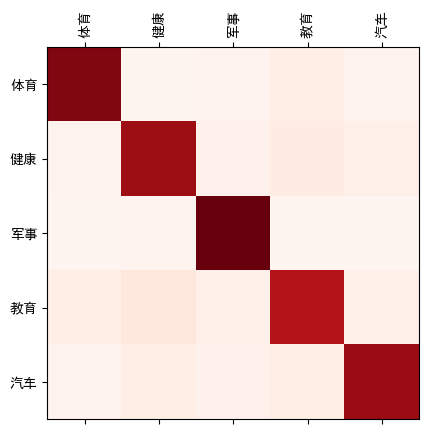

In [38]:
rcParams['font.family'] = 'SimHei'
plt.matshow(C_M, cmap=plt.cm.Reds)  # cmap指定颜色系

# 显示刻度与标签
ticks = np.array(range(len(label_names)))
plt.xticks(ticks, label_names, rotation=90)  # 将标签印在x轴坐标上, 旋转90度
plt.yticks(ticks, label_names)  # 将标签印在y轴坐标上
plt.show()
# plt.savefig("./image/confusion_matrix.png")  # 直接保存为图片

----

# 7. 推理

- 推理实现也是常见的流程：
    - 加载模型
    - 预处理需要分类的文本
    - 预测计算
    - 处理预测结果

In [40]:
import torch as T
import numpy as np
import torch.nn.functional as F
# 记载模型
model = T.load('model.pth', weights_only=False)
# 加载标签库与字库
label_dict, char_dict = load_file_file()
# 交换key与value
label_dict_rev = {v: k for k, v in label_dict.items()}

# 分类预测文本
text = '盖世汽车讯，特斯拉去年击败了宝马，夺得了美国豪华汽车市场的桂冠，并在今年实现了开门红。1月份，得益于大幅降价和7500美元美国电动汽车税收抵免，特斯拉再度击败宝马，蝉联了美国豪华车销冠，并且注册量超过了排名第三的梅赛德斯-奔驰和排名第四的雷克萨斯的总和。根据Experian的数据，在所有豪华品牌中，1月份，特斯拉在美国的豪华车注册量为49，917辆，同比增长34%；宝马的注册量为31，070辆，同比增长2.5%；奔驰的注册量为23，345辆，同比增长7.3%；雷克萨斯的注册量为23，082辆，同比下降6.6%。奥迪以19，113辆的注册量排名第五，同比增长38%。凯迪拉克注册量为13，220辆，较去年同期增长36%，排名第六。排名第七的讴歌的注册量为10，833辆，同比增长32%。沃尔沃汽车排名第八，注册量为8，864辆，同比增长1.8%。路虎以7，003辆的注册量排名第九，林肯以6，964辆的注册量排名第十。'

# 文本向量化，因为text_feature实现的缘故，其中需要一个labels参数，但实际该参数在推理没有意义，所以使用随意一个标签代替。
labels, contents = ['汽车'], [text]
samples, y_true = text_feature(labels, contents, label_dict, char_dict)

# 转化为张量
x = T.from_numpy(np.array(samples)).long()
print(x.shape)
# 预测，注意x的形状按照我们前面说的，需要满足特定的形状
y_pred = model(x) 

# 转换为概率
y_numpy = F.softmax(y_pred, dim=1).detach().numpy()
# 去最大概率的下标作为预测标签编号（因为可能存在多个文本预测结果）
predict_list = np.argmax(y_numpy, axis=1).tolist()
# 查询输出预测标签
for i, predict in enumerate(predict_list):
    print(f"第{i+1}个文本，预测标签为： {label_dict_rev[predict]}")


torch.Size([1, 200])
第1个文本，预测标签为： 汽车


-----